In [32]:
from langgraph.graph import START, END, StateGraph, MessagesState, add_messages
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, RemoveMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence
from langchain_openai.chat_models import ChatOpenAI
from typing import Literal, Annotated
import sys
sys.path.append("..")
import config
from langgraph.checkpoint.memory import InMemorySaver # short term memory
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver # long term memory

In [2]:
chat = ChatOpenAI(
    model = "openai/gpt-4",
    api_key=config.apiKey2,
    temperature = 0,
    max_tokens = 150,
    base_url="https://openrouter.ai/api/v1"
)

In [3]:
def askQ(state: MessagesState) -> MessagesState:
    for i in state["messages"]:
        i.pretty_print() 
    q = "What is your question?"
    print(q)
    return MessagesState(messages = [AIMessage(q), HumanMessage(input())])
    
def askanQ(state: MessagesState) -> MessagesState:
    for i in state["messages"]:
        i.pretty_print() 
    q = "Whould you like to ask another question? (yes/no)"
    print(q)
    return MessagesState(messages = [AIMessage(q), HumanMessage(input())])

In [4]:
def trimMessages(state: MessagesState) -> MessagesState:
    # only final 5 messages before going to another
    removeMes = [RemoveMessage(id = i.id) for i in state["messages"][:-5]]
    return MessagesState(messages = removeMes) # fed as an argument to the reducer, add_messages now appends and removes

In [5]:
def routing(state: MessagesState) -> Literal["trim_messages", "__end__"]:
    if state["messages"][-1].content == "yes":
        return "trim_messages"
    else:
        return "__end__"
        
def chatbot(state: MessagesState) -> MessagesState:
    res = chat.invoke(state["messages"])
    res.pretty_print()
    return MessagesState(messages = [res])

In [6]:
g = StateGraph(MessagesState)
g.add_node("ask_question", askQ)
g.add_node("chatbot", chatbot)
g.add_node("ask_another_question", askanQ)
g.add_node("trim_messages", trimMessages)
g.add_edge(START, "ask_question")
g.add_edge("ask_question", "chatbot")
g.add_edge("chatbot", "ask_another_question")
g.add_edge("trim_messages", "ask_question")
g.add_conditional_edges(source = "ask_another_question", path = routing)

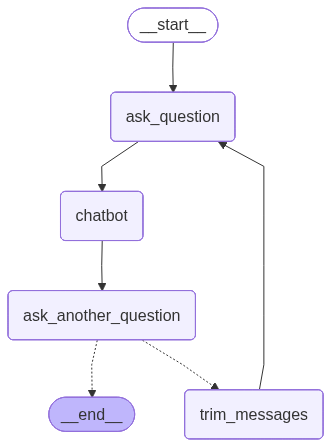

In [7]:
graph = g.compile()
graph

In [8]:
#graph.invoke(MessagesState(messages = []))

#### Summarizing for long convers

In [9]:
from langchain_core.messages import SystemMessage

In [10]:
class State(MessagesState):
    summary: str

In [11]:
def askQ(state: State) -> State:
    q = "What is your question?"
    print(q)
    return State(messages = [AIMessage(q), HumanMessage(input())])
def chatbot(state: State) -> State:
    for i in state["messages"]:
        i.pretty_print()

    sy = f"""
    Here is a quick summary of what's been discussed so far:
    {state.get("summary","")}
    Keep this in mind as you answer the next question.
    """
    res = chat.invoke([SystemMessage(sy)] + state["messages"])
    res.pretty_print()
    return State(messages = [res])
def askanQ(state: State) -> State:
    q = "Whould you like to ask another question? (yes/no)"
    print(q)
    return State(messages = [AIMessage(q), HumanMessage(input())])


In [17]:
def sumDelMessages(state: State) -> State:
    newConvs = ""
    for i in state["messages"]:
        newConvs += f"{i.type}: {i.content}\n\n"

    # it seems that AI cant combine prev summary with the new one, so I'll just concat it
    summaryInstructions = f"""
        Create a very short summary of a new conversation.
        {newConvs}"""
    
    summary = chat.invoke([HumanMessage(summaryInstructions)])
    
    removeMes = [RemoveMessage(id = i.id) for i in state["messages"][:]]
    return State(messages = removeMes, summary = state.get("summary", "") + summary.content)

In [13]:
def routing(state: State) -> Literal["sum_del_messages", "__end__"]:
    if state["messages"][-1].content == "yes":
        return "sum_del_messages"
    else:
        return "__end__"

In [14]:
g = StateGraph(MessagesState)
g.add_node("ask_question", askQ)
g.add_node("chatbot", chatbot)
g.add_node("ask_another_question", askanQ)
g.add_node("sum_del_messages", sumDelMessages)
g.add_edge(START, "ask_question")
g.add_edge("ask_question", "chatbot")
g.add_edge("chatbot", "ask_another_question")
g.add_edge("sum_del_messages", "ask_question")
g.add_conditional_edges(source = "ask_another_question", path = routing)

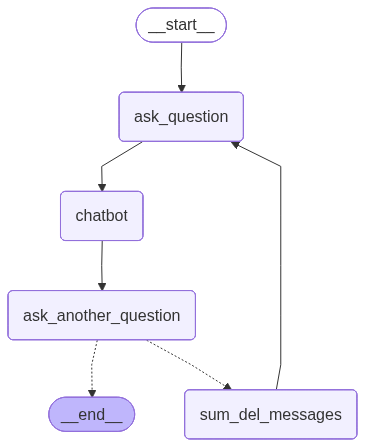

In [34]:
checkpointer = InMemorySaver()
dbPath = "C:/Users/Josip/Desktop/AI/llm/langgraph/langgraph.db"
con = sqlite3.connect(database = dbPath, check_same_thread = False)
# checkpointer = SqliteSaver(con)
graph = g.compile(checkpointer)
graph

In [22]:
config1 = {"configurable": {"thread_id": "1"}}
config2 = {"configurable": {"thread_id": "2"}}

In [24]:
# thread level persistance
graph.invoke(State(), config1)

What is your question?


 What did gorilla do that was very impressive?


================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Create a made up story about a gorilla who benched 1k kilos
================================== Ai Message ==================================

Once upon a time, in the heart of the African jungle, lived a gorilla named Goliath. Goliath was not your average gorilla. He was twice the size of the other gorillas and had a strength that was unmatched in the entire animal kingdom. 

Goliath was known far and wide for his incredible strength. But he was not satisfied. He wanted to prove to himself and to the world that he was the strongest creature alive. So, he decided to take on a challenge that no other animal had ever attempted before - to bench press 1,000 kilos.

Word spread quickly throughout the jungle about Goliath's daring challenge. Animals from all corners of the jungle came to witness this extraor

 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='84808a81-f581-4913-a3cf-9db4d2271d60'),
  HumanMessage(content='Create a made up story about a gorilla who benched 1k kilos', additional_kwargs={}, response_metadata={}, id='f5da82b3-3547-4ae5-b291-84afb2f246ba'),
  AIMessage(content="Once upon a time, in the heart of the African jungle, lived a gorilla named Goliath. Goliath was not your average gorilla. He was twice the size of the other gorillas and had a strength that was unmatched in the entire animal kingdom. \n\nGoliath was known far and wide for his incredible strength. But he was not satisfied. He wanted to prove to himself and to the world that he was the strongest creature alive. So, he decided to take on a challenge that no other animal had ever attempted before - to bench press 1,000 kilos.\n\nWord spread quickly throughout the jungle about Goliath's daring challenge. Animals from all corners of the jungle came to witn

In [26]:
graphStates = [i for i in graph.get_state_history(config1)]

In [30]:
for i in graphStates[::-1]:
    print(f"""
Messages: {i.values["messages"]}
Summary: {i.values.get("summary", "")}
Next: {i.next}
Step: {i.metadata["step"]}
""")


Messages: []
Summary: 
Next: ('__start__',)
Step: -1


Messages: []
Summary: 
Next: ('ask_question',)
Step: 0


Messages: [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='84808a81-f581-4913-a3cf-9db4d2271d60'), HumanMessage(content='Create a made up story about a gorilla who benched 1k kilos', additional_kwargs={}, response_metadata={}, id='f5da82b3-3547-4ae5-b291-84afb2f246ba')]
Summary: 
Next: ('chatbot',)
Step: 1


Messages: [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='84808a81-f581-4913-a3cf-9db4d2271d60'), HumanMessage(content='Create a made up story about a gorilla who benched 1k kilos', additional_kwargs={}, response_metadata={}, id='f5da82b3-3547-4ae5-b291-84afb2f246ba'), AIMessage(content="Once upon a time, in the heart of the African jungle, lived a gorilla named Goliath. Goliath was not your average gorilla. He was twice the size of the other gorillas and had a strength that was unma